In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv("../data/raw/student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (395, 33)


In [5]:
def categorize_performance(grade):
    if grade <= 9:
        return "At Risk"
    elif grade <= 14:
        return "Average"
    else:
        return "High Performance"


df["performance_category"] = df["G3"].apply(categorize_performance)

In [6]:
df[["G3", "performance_category"]].head(10)

,G3,performance_category
0,6,At Risk
1,6,At Risk
2,10,Average
3,15,High Performance
4,10,Average
5,15,High Performance
6,11,Average
7,6,At Risk
8,19,High Performance
9,15,High Performance


In [7]:
print(df["performance_category"].value_counts())

performance_category
Average             192
At Risk             130
High Performance     73
Name: count, dtype: int64


In [8]:
X = df.drop(
    columns=[
        "G1",
        "G2",
        "G3",
        "performance_category"
    ]
)

y = df["performance_category"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (395, 30)
Target shape: (395,)


In [9]:
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (316, 30)
Testing features: (79, 30)

Training target distribution:
performance_category
Average             154
At Risk             104
High Performance     58
Name: count, dtype: int64

Testing target distribution:
performance_category
Average             38
At Risk             26
High Performance    15
Name: count, dtype: int64


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [13]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['At Risk','Average','High Performance']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['school','sex','age',...,'Walc','health','absences']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [14]:
y_pred_logistic = logistic_model.predict(X_test)

In [15]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:", logistic_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Accuracy: 0.4430379746835443

Classification Report:
                  precision    recall  f1-score   support

         At Risk       0.45      0.35      0.39        26
         Average       0.49      0.61      0.54        38
High Performance       0.25      0.20      0.22        15

        accuracy                           0.44        79
       macro avg       0.40      0.38      0.38        79
    weighted avg       0.43      0.44      0.43        79



In [16]:
print(X.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [17]:
print("\nDoes X contain G1?", "G1" in X.columns)
print("Does X contain G2?", "G2" in X.columns)
print("Does X contain G3?", "G3" in X.columns)


Does X contain G1? False
Does X contain G2? False
Does X contain G3? False


In [18]:
def evaluate_model(model, X_test, y_test, model_name):
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print("=" * 50)
    print(f"{model_name} Results")
    print("=" * 50)
    
    print(f"\nAccuracy: {accuracy:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    return accuracy, y_pred

In [19]:
logistic_accuracy, y_pred_logistic = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

Logistic Regression Results

Accuracy: 0.4430

Classification Report:
                  precision    recall  f1-score   support

         At Risk       0.45      0.35      0.39        26
         Average       0.49      0.61      0.54        38
High Performance       0.25      0.20      0.22        15

        accuracy                           0.44        79
       macro avg       0.40      0.38      0.38        79
    weighted avg       0.43      0.44      0.43        79


Confusion Matrix:
[[ 9 15  2]
 [ 8 23  7]
 [ 3  9  3]]


In [20]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5,
                min_samples_split=5,
                min_samples_leaf=2
            )
        )
    ]
)

In [21]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['At Risk','Average','High Performance']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['school','sex','age',...,'Walc','health','absences']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [22]:
decision_tree_accuracy, y_pred_tree = evaluate_model(
    decision_tree_model,
    X_test,
    y_test,
    "Decision Tree"
)

Decision Tree Results

Accuracy: 0.5063

Classification Report:
                  precision    recall  f1-score   support

         At Risk       0.48      0.38      0.43        26
         Average       0.55      0.74      0.63        38
High Performance       0.29      0.13      0.18        15

        accuracy                           0.51        79
       macro avg       0.44      0.42      0.41        79
    weighted avg       0.48      0.51      0.48        79


Confusion Matrix:
[[10 14  2]
 [ 7 28  3]
 [ 4  9  2]]


In [23]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced"
            )
        )
    ]
)

In [24]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['At Risk','Average','High Performance']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['school','sex','age',...,'Walc','health','absences']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [25]:
random_forest_accuracy, y_pred_rf = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest Results

Accuracy: 0.4810

Classification Report:
                  precision    recall  f1-score   support

         At Risk       0.54      0.50      0.52        26
         Average       0.50      0.53      0.51        38
High Performance       0.33      0.33      0.33        15

        accuracy                           0.48        79
       macro avg       0.46      0.45      0.46        79
    weighted avg       0.48      0.48      0.48        79


Confusion Matrix:
[[13 12  1]
 [ 9 20  9]
 [ 2  8  5]]


In [26]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [27]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [28]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

In [29]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metrice

In [30]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Macro F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best Cross-Validation Macro F1 Score:
0.5137684646787998


In [31]:
best_random_forest = grid_search.best_estimator_

tuned_rf_accuracy, y_pred_tuned_rf = evaluate_model(
    best_random_forest,
    X_test,
    y_test,
    "Tuned Random Forest"
)


Tuned Random Forest Results

Accuracy: 0.4304

Classification Report:
                  precision    recall  f1-score   support

         At Risk       0.42      0.38      0.40        26
         Average       0.47      0.45      0.46        38
High Performance       0.37      0.47      0.41        15

        accuracy                           0.43        79
       macro avg       0.42      0.43      0.42        79
    weighted avg       0.43      0.43      0.43        79


Confusion Matrix:
[[10 13  3]
 [12 17  9]
 [ 2  6  7]]


In [32]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Predictions from each model
lr_pred = logistic_model.predict(X_test)
dt_pred = decision_tree_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)
best_rf_model = grid_search.best_estimator_
tuned_rf_pred = best_rf_model.predict(X_test)

# Create comparison results
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_rf_pred)
    ],
    "Macro F1": [
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, dt_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, tuned_rf_pred, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, tuned_rf_pred, average="weighted")
    ]
})

model_results.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro F1,Weighted F1
2,Random Forest,0.481013,0.455385,0.481104
3,Tuned Random Forest,0.430380,0.423741,0.430835
1,Decision Tree,0.506329,0.412188,0.477231
0,Logistic Regression,0.443038,0.384901,0.431291


In [33]:
best_rf_model = grid_search.best_estimator_

tuned_rf_pred = best_rf_model.predict(X_test)

print("Tuned Random Forest predictions created successfully.")

Tuned Random Forest predictions created successfully.


In [34]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Predictions from each model
lr_pred = logistic_model.predict(X_test)
dt_pred = decision_tree_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)

# Get predictions from tuned Random Forest
best_rf_model = grid_search.best_estimator_
tuned_rf_pred = best_rf_model.predict(X_test)

# Create comparison table
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_rf_pred)
    ],
    "Macro F1": [
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, dt_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, tuned_rf_pred, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, tuned_rf_pred, average="weighted")
    ]
})

model_results = model_results.sort_values(
    by="Macro F1",
    ascending=False
)

print(model_results)

                 Model  Accuracy  Macro F1  Weighted F1
2        Random Forest  0.481013  0.455385     0.481104
3  Tuned Random Forest  0.430380  0.423741     0.430835
1        Decision Tree  0.506329  0.412188     0.477231
0  Logistic Regression  0.443038  0.384901     0.431291


## Step 7 - Final Model Evaluation



In [35]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Final model
final_model = random_forest_model

# Make predictions
final_predictions = final_model.predict(X_test)

# Calculate accuracy
final_accuracy = accuracy_score(y_test, final_predictions)

print("=" * 50)
print("FINAL MODEL: RANDOM FOREST")
print("=" * 50)

print(f"\nAccuracy: {final_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

print("\nConfusion Matrix:")
final_cm = confusion_matrix(y_test, final_predictions)
print(final_cm)

FINAL MODEL: RANDOM FOREST

Accuracy: 0.4810

Classification Report:
                  precision    recall  f1-score   support

         At Risk       0.54      0.50      0.52        26
         Average       0.50      0.53      0.51        38
High Performance       0.33      0.33      0.33        15

        accuracy                           0.48        79
       macro avg       0.46      0.45      0.46        79
    weighted avg       0.48      0.48      0.48        79


Confusion Matrix:
[[13 12  1]
 [ 9 20  9]
 [ 2  8  5]]


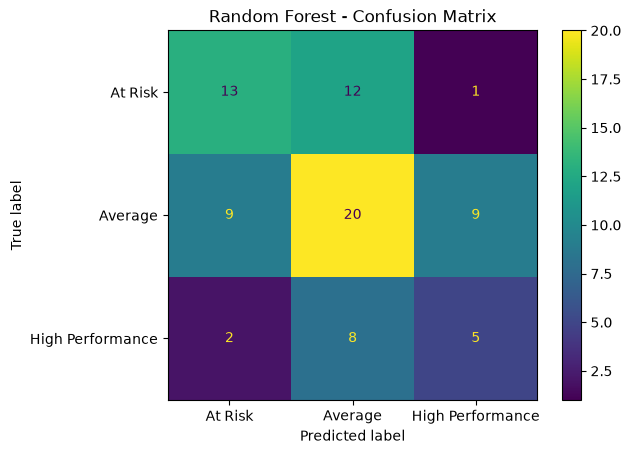

In [36]:
# Define class labels
class_labels = ["At Risk", "Average", "High Performance"]

# Create confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=class_labels
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [37]:
# Get the feature names after preprocessing
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 processed feature names:")
print(feature_names[:20])

Number of processed features: 56

First 20 processed feature names:
['num__age' 'num__Medu' 'num__Fedu' 'num__traveltime' 'num__studytime'
 'num__failures' 'num__famrel' 'num__freetime' 'num__goout' 'num__Dalc'
 'num__Walc' 'num__health' 'num__absences' 'cat__school_GP'
 'cat__school_MS' 'cat__sex_F' 'cat__sex_M' 'cat__address_R'
 'cat__address_U' 'cat__famsize_GT3']


In [38]:
# Get feature importances from the Random Forest model
importances = random_forest_model.named_steps["model"].feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 15 features
print("Top 15 Most Important Features:")
print(feature_importance_df.head(15))

Top 15 Most Important Features:
            Feature  Importance
5     num__failures    0.069733
12    num__absences    0.068328
8        num__goout    0.049106
1         num__Medu    0.043487
11      num__health    0.043127
0          num__age    0.039437
10        num__Walc    0.037158
7     num__freetime    0.034967
2         num__Fedu    0.033450
9         num__Dalc    0.031554
4    num__studytime    0.028238
6       num__famrel    0.024076
25  cat__Mjob_other    0.022369
16       cat__sex_M    0.019205
3   num__traveltime    0.019138


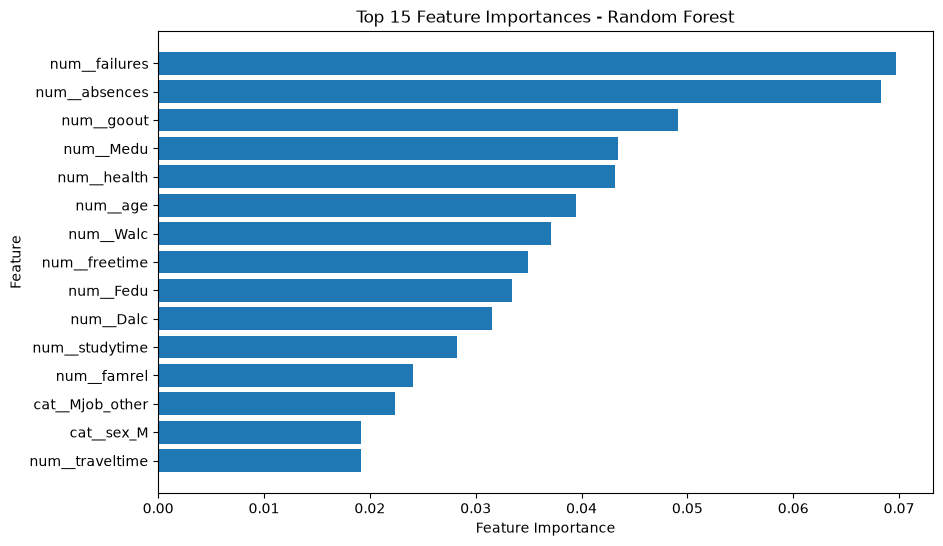

In [39]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.gca().invert_yaxis()

plt.show()

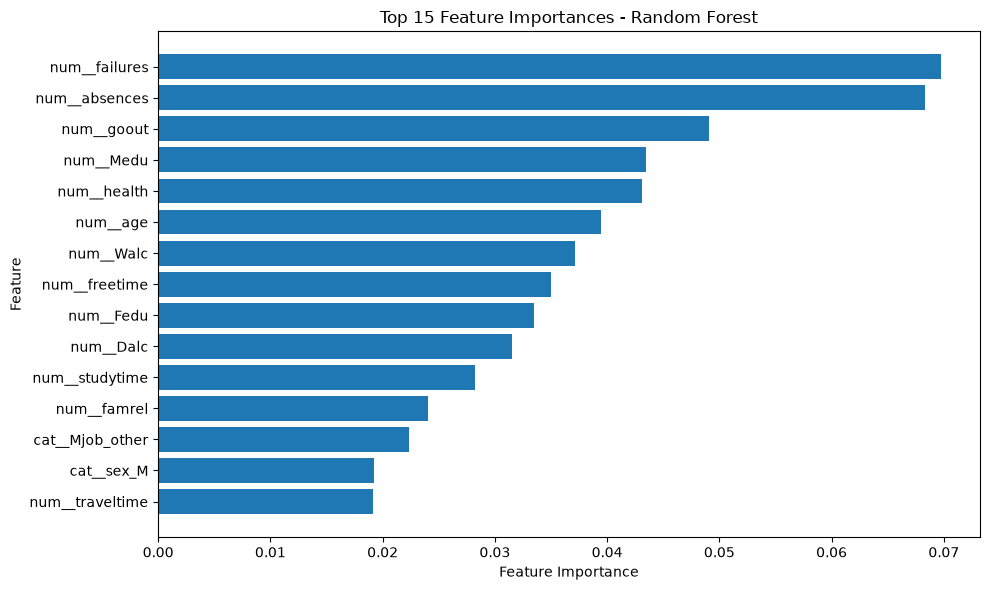

In [40]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()